# HW5 – Exploratory Data Analysis with Python

---
**Author:** Ajay Singh  
**Date:** March 28, 2026  
**Course:** MIS 5470 – Practical Computing for Data Analytics  
**Assignment:** HW5 – EDA with Python  

---

In [1]:
# Data load and preparation

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Load data
df = pd.read_csv('kc_house_data_original.csv')

# Parse date column
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
df['year_month'] = df['date'].dt.to_period('M')

print(f"Shape: {df.shape}")
df.head()

Shape: (21613, 22)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year_month
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014-10
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014-12
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015-02
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014-12
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015-02


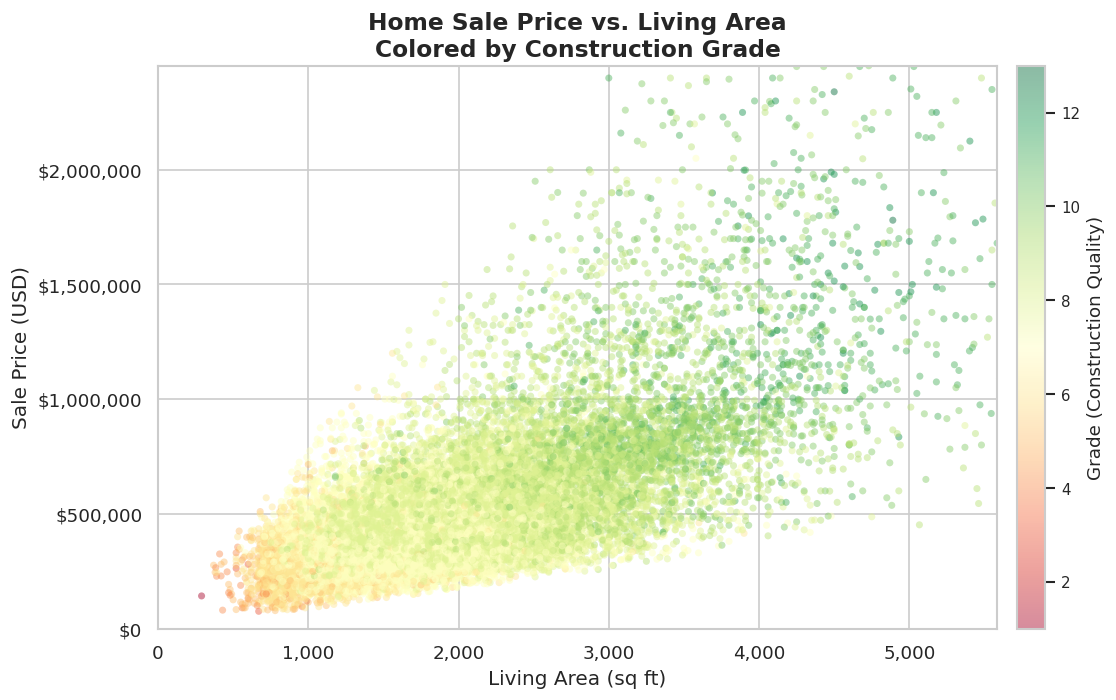

In [7]:
# Scatter plot: Price vs Size  of the data markers (Sq Ft)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df['sqft_living'],
    df['price'],
    c=df['grade'],
    cmap='RdYlGn',
    alpha=0.45,
    s=18,
    linewidths=0
)

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Grade (Construction Quality)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

ax.set_xlabel('Living Area (sq ft)', fontsize=12)
ax.set_ylabel('Sale Price (USD)', fontsize=12)
ax.set_title('Home Sale Price vs. Living Area\nColored by Construction Grade', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, df['sqft_living'].quantile(0.995))
ax.set_ylim(0, df['price'].quantile(0.995))

plt.tight_layout()
plt.savefig('plot1_scatter.png', bbox_inches='tight')
plt.show()





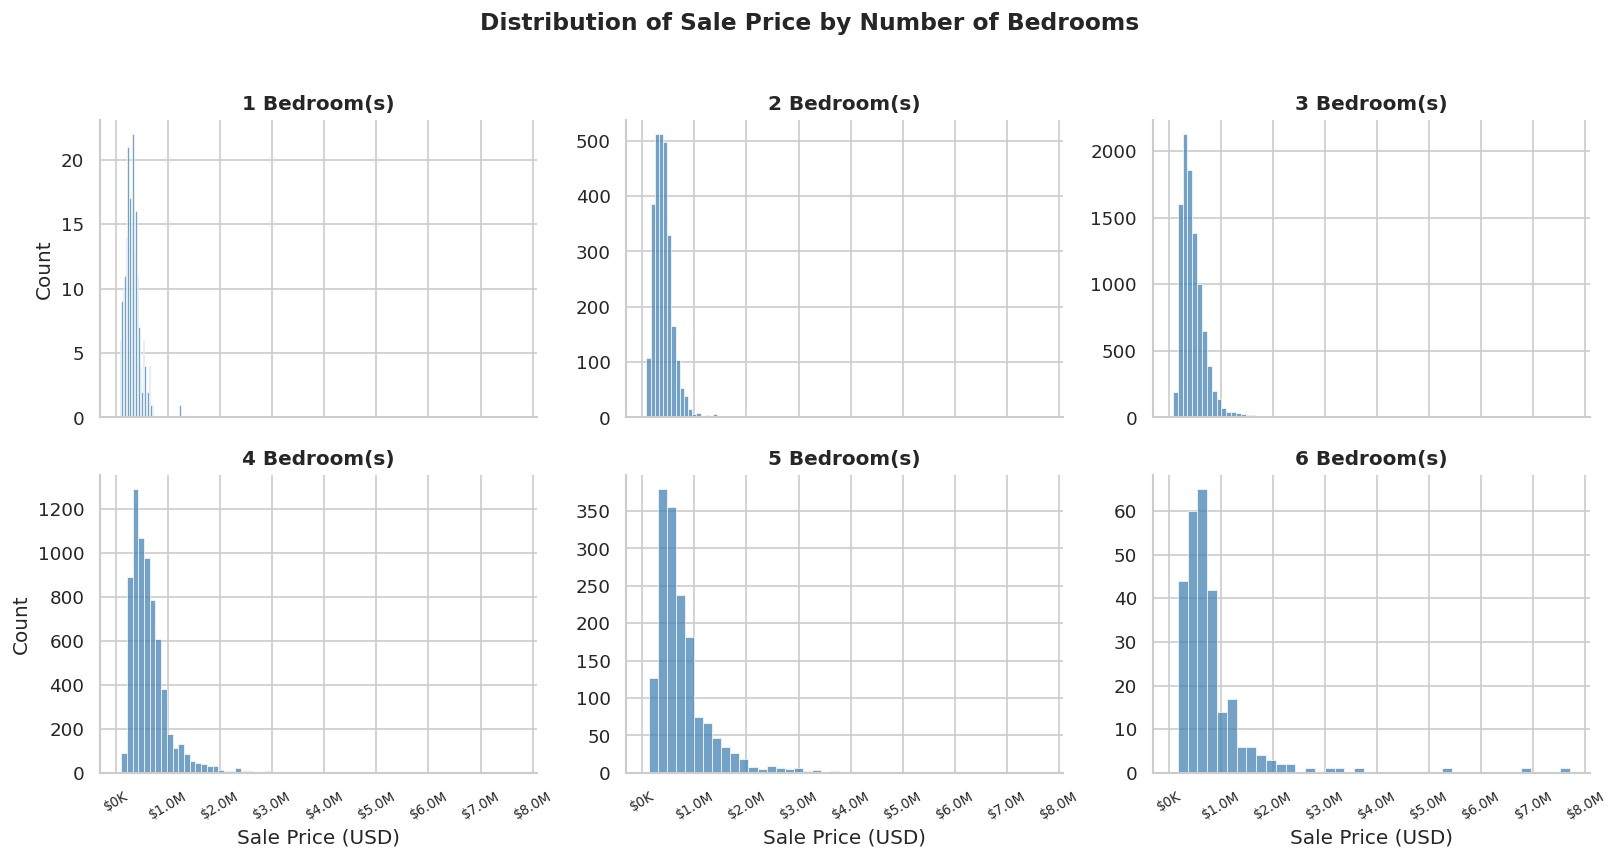

In [8]:
# faceted histograms Plot: Price by Bedrooms

df_bed = df[df['bedrooms'].between(1, 6)].copy()

g = sns.FacetGrid(
    df_bed,
    col='bedrooms',
    col_wrap=3,
    height=3.5,
    aspect=1.3,
    sharey=False
)

g.map_dataframe(
    sns.histplot,
    x='price',
    bins=40,
    color='steelblue',
    edgecolor='white',
    linewidth=0.4
)

g.set_titles(col_template='{col_name} Bedroom(s)', size=12, fontweight='bold')
g.set_axis_labels('Sale Price (USD)', 'Count')

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'
    ))
    ax.tick_params(axis='x', rotation=30, labelsize=8)

g.figure.suptitle('Distribution of Sale Price by Number of Bedrooms',
                   y=1.02, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot2_faceted_hist.png', bbox_inches='tight')
plt.show()

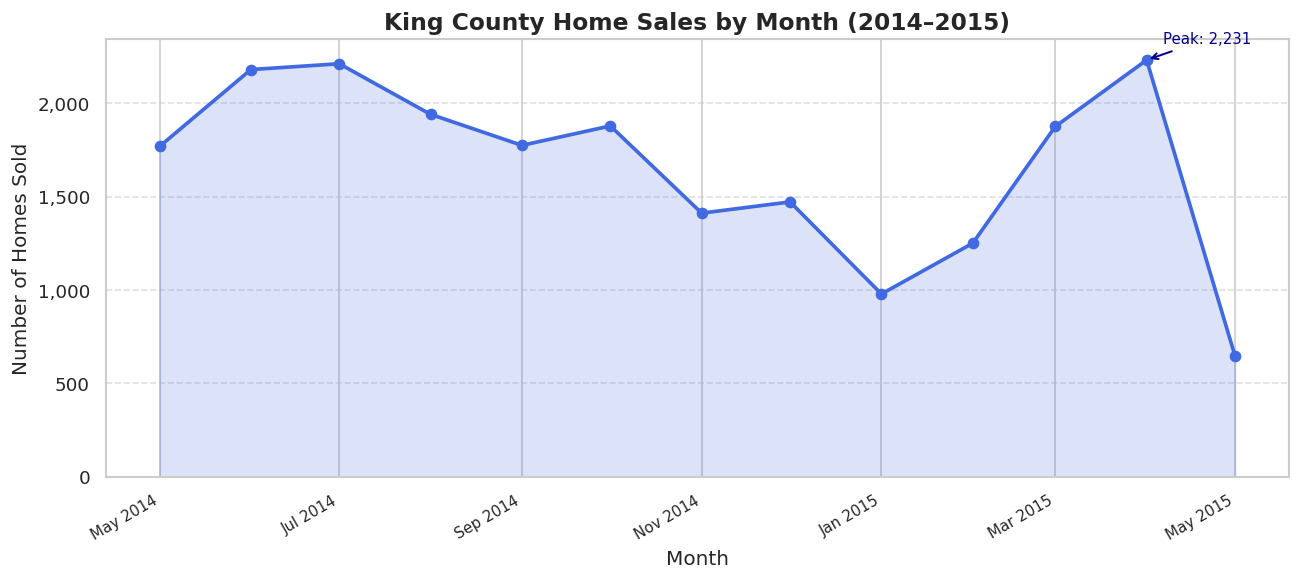

In [9]:
# Plot 3 — Time Series: Homes Sold by Month

monthly_sales = (
    df.groupby('year_month')
      .size()
      .reset_index(name='sales_count')
)
monthly_sales['month_dt'] = monthly_sales['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 5))

ax.fill_between(monthly_sales['month_dt'], monthly_sales['sales_count'],
                alpha=0.18, color='royalblue')
ax.plot(monthly_sales['month_dt'], monthly_sales['sales_count'],
        color='royalblue', linewidth=2.2, marker='o', markersize=6, zorder=3)

# identify peak month
peak = monthly_sales.loc[monthly_sales['sales_count'].idxmax()]
ax.annotate(
    f"Peak: {peak['sales_count']:,}",
    xy=(peak['month_dt'], peak['sales_count']),
    xytext=(10, 10), textcoords='offset points',
    fontsize=9, color='darkblue',
    arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.2)
)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Homes Sold', fontsize=12)
ax.set_title('King County Home Sales by Month (2014–2015)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right', fontsize=9)
ax.set_ylim(0)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('plot3_time_series.png', bbox_inches='tight')
plt.show()


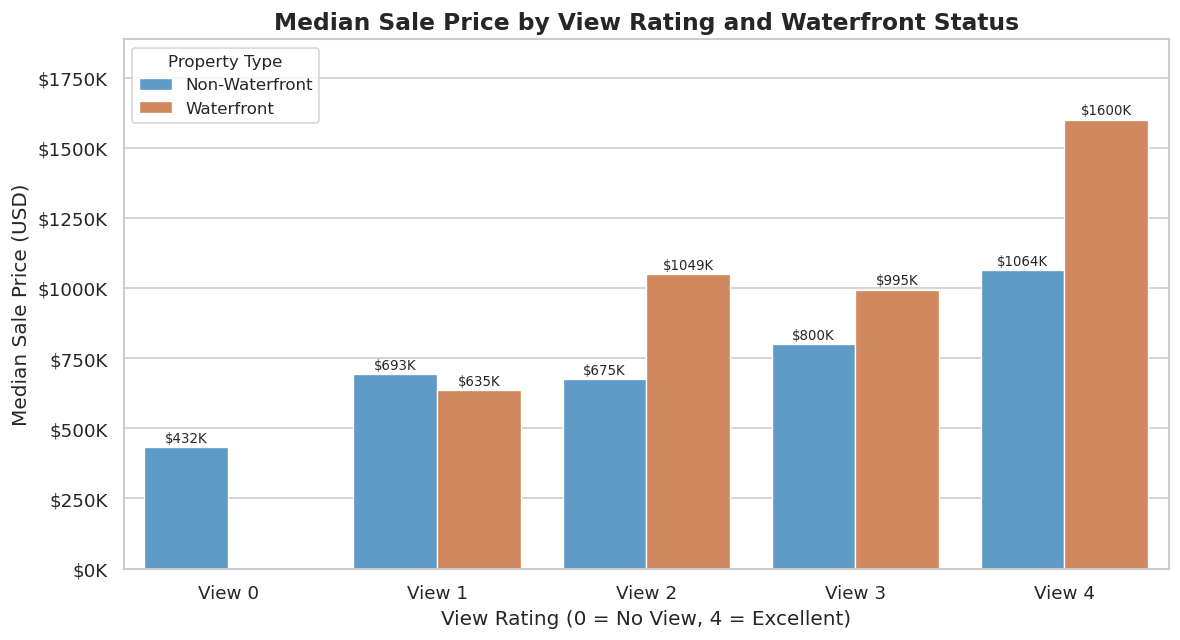

In [10]:
# Plot 4 — Bar Chart: Median Price by Waterfront & View Rating
df['waterfront_label'] = df['waterfront'].map({0: 'Non-Waterfront', 1: 'Waterfront'})
df['view_label'] = df['view'].apply(lambda v: f'View {v}')

grp = (
    df.groupby(['view_label', 'waterfront_label'])['price']
      .median()
      .reset_index(name='median_price')
)

fig, ax = plt.subplots(figsize=(10, 5.5))

palette = {'Non-Waterfront': '#4C9ED9', 'Waterfront': '#E5834C'}
sns.barplot(
    data=grp,
    x='view_label', y='median_price',
    hue='waterfront_label',
    palette=palette,
    edgecolor='white',
    linewidth=0.8,
    ax=ax
)

# Price labels on bars
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            h + 8000,
            f'${h/1e3:.0f}K',
            ha='center', va='bottom', fontsize=8
        )

ax.set_xlabel('View Rating (0 = No View, 4 = Excellent)', fontsize=12)
ax.set_ylabel('Median Sale Price (USD)', fontsize=12)
ax.set_title('Median Sale Price by View Rating and Waterfront Status', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend(title='Property Type', fontsize=10, title_fontsize=10)
ax.set_ylim(0, grp['median_price'].max() * 1.18)

plt.tight_layout()
plt.savefig('plot4_waterfront_view.png', bbox_inches='tight')
plt.show()

In [12]:
!jupyter nbconvert --to html HW5_EDA_with_Python.ipynb

[NbConvertApp] Converting notebook HW5_EDA_with_Python.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 1071974 bytes to HW5_EDA_with_Python.html
